здесь будет описание

**REQUIRE:** папка bg (с фонами)

# Init

In [1]:
from IPython.core.magic import register_cell_magic
# from IPython.core import getipython
import sys
import os

def detect_env():
    if 'google.colab' in sys.modules: return 'COLAB'
    if os.environ.get('KAGGLE_KERNEL_RUN_TYPE'): return 'KAGGLE'
    return 'LOCAL'

ENV = detect_env()

@register_cell_magic
def run_on(line, cell):
    """
    Запускает ячейку, если текущая среда (COLAB/KAGGLE/LOCAL)
    в списке аргументов e.g.: %%run_on COLAB KAGGLE
    """
    allowed_envs = [e.strip().upper() for e in line.split()]
    if ENV in allowed_envs:
        get_ipython().run_cell(cell)  # type: ignore
    else:
        print(">>> [Skipped] Cell skipped")

ENV

'KAGGLE'

In [2]:
%%run_on COLAB
import kagglehub
import os
from google.colab import userdata

COMPETITION_NAME = 'dl-lab-3-product-segmentation'

# Читаем серктеницу колаба
kaggle_username = userdata.get('KAGGLE_USERNAME')
kaggle_key = userdata.get('KAGGLE_KEY')

os.environ['KAGGLE_USERNAME'] = kaggle_username
os.environ['KAGGLE_KEY'] = kaggle_key
os.environ['KAGGLEHUB_CACHE'] = '/'

!mkdir -p ~/.kaggle
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    f.write(f'{{"username":"{kaggle_username}","key":"{kaggle_key}"}}')
!chmod 600 ~/.kaggle/kaggle.json
print("Kaggle API credentials configured successfully!")

dl_lab_3_product_segmentation_path = kagglehub.competition_download(COMPETITION_NAME)
print('Data source import complete.')

>>> [Skipped] Cell skipped


In [3]:
%%run_on COLAB
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

DRIVE_CHECKPOINT_DIR = Path("/content/drive/MyDrive/segmentation_checkpoints")
DRIVE_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Checkpoints will be saved to: {DRIVE_CHECKPOINT_DIR}")

>>> [Skipped] Cell skipped


In [ ]:
%%run_on COLAB KAGGLE
# ~2m
%pip install segmentation-models-pytorch timm opencv-python pandas
%pip uninstall -y torch torchvision
%pip install --no-cache-dir torch==2.7.0 torchvision==0.22.0 --index-url https://download.pytorch.org/whl/cu118

In [4]:
import cv2
import numpy as np
import torch
from tqdm import tqdm

import os
import random
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import segmentation_models_pytorch as smp

torch.backends.cudnn.benchmark = True
torch.backends.cudnn.enabled = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision('high')

# Конфиг и сиды

In [5]:
#### ПУТИ ####
BACKUP_TO_DRIVE = True
BACKUP_TO_DRIVE = BACKUP_TO_DRIVE and ENV != 'LOCAL'

# Входы
BG_DIR_MAP = {'LOCAL': Path('./bg'),
              'COLAB': Path('./bg'),
              'KAGGLE': Path('/kaggle/input/datasets/aaaaa982/dl-lab-3-bg/bg')}
BG_DIR = BG_DIR_MAP[ENV]
DATA_ROOT_MAP = {'LOCAL':  Path('./data/train'),
                 'COLAB':  Path('/competitions/dl-lab-3-product-segmentation/train'),
                 'KAGGLE': Path('/kaggle/input/competitions/dl-lab-3-product-segmentation/train')}
DATA_ROOT = DATA_ROOT_MAP[ENV]
IMAGES_DIR = DATA_ROOT / "images"
MASKS_DIR = DATA_ROOT / "masks"

SPLIT_TXT = Path('/kaggle/input/datasets/aaaaa982/123123/split.txt')

# Выходы
BUILDED_DS_DIR = Path("./builded_dataset")
BUILDED_DS_DIR.mkdir(parents=True, exist_ok=True)

SAVE_DIR = Path("./seg_train_runs")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

DRIVE_CHECKPOINT_DIR = Path("/content/drive/MyDrive/segmentation_checkpoints")
if ENV == 'COLAB' and BACKUP_TO_DRIVE:
    DRIVE_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

In [6]:
VAL_RATIO = .20
SEED = 123

random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch_random_gen = torch.Generator()
torch_random_gen.manual_seed(SEED)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed) # хоть по идее и форкает, но на всякий случай


# Preprocessing

## Utils

In [7]:
from concurrent.futures import ThreadPoolExecutor
from typing import Literal

def get_loc(fn):
    return fn.split('_')[0]


LOCS = defaultdict(list)
for f in sorted(IMAGES_DIR.glob('*.jpg')):
    stem = f.stem
    loc = get_loc(stem)
    LOCS[loc].append(stem)


def load_batch(paths, channels_num: Literal[1, 3] = 3, max_workers:int|None=None) -> np.ndarray:
    if not paths: return np.array([], 'u1')
    flag = int(channels_num == 3)
    im0: np.ndarray = cv2.imread(paths[0], flags=flag)  # type: ignore
    h, w = im0.shape[:2]  # AttribureError если None
    b = len(paths)
    shape = (b,h,w,3) if channels_num == 3 else (b,h,w)
    ims = np.empty(shape, dtype=np.uint8)
    ims[0] = im0

    def worker(i):
        try:
            ims[i] = cv2.imread(paths[i], flag)  # type: ignore
        except ValueError as e:
            raise ValueError(f"Disappointing file: {paths[i]}") from e

    if b > 1:
        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            list(executor.map(worker, range(1, b)))
    return ims

## Build

In [8]:
def spatial_priors(
    ms_dir:Path = MASKS_DIR,
    loc2stems = LOCS,
    _kg=33, _km=17, silent=False
):
    priors: dict[str, np.ndarray] = {}

    it = (loc2stems.items() if silent
          else tqdm(loc2stems.items(), desc="Calc-ing priors"))

    for ip, stems in it:
        paths = [f"{ms_dir}/{s}.png" for s in stems]
        ms = load_batch(paths, channels_num=1)
        sp_raw = np.mean(ms, axis=0, dtype=np.float32)
        del ms
        sp = cv2.GaussianBlur(sp_raw, (_kg, _kg), 0)  # type: ignore
        sp[sp_raw < 2.55] = 0.0
        res = np.empty(sp.shape, 'u1')
        cv2.normalize(sp, res, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
        cv2.medianBlur(res, _km, dst=res)
        priors[ip] = res

    return priors


def bg_diff(_kd=0.5, _ks=1.75, _km=13):
    _x = np.arange(256, dtype=np.float32)
    _y = np.arange(256, dtype=np.float32)
    lut = np.clip(_x[:,None] * (_kd + _ks) - _y[None,:] * _ks, 0, 255).round().astype(np.uint8)

    def job(im, bg):
        nonlocal lut, _km
        abs_diff = cv2.absdiff(im, bg)
        max_diff = np.max(abs_diff, axis=-1)
        min_diff = np.min(abs_diff, axis=-1)
        res = lut[max_diff, min_diff]
        cv2.medianBlur(res, _km, dst=res)
        return res
    return job


def bgs_load(bg_dir: Path = BG_DIR, loc2stems=LOCS):
    bgs: dict[str, np.ndarray] = {}

    for loc in loc2stems:
        bgp = bg_dir / f"{loc}.jpg"
        bg = cv2.imread(str(bgp), cv2.IMREAD_COLOR)
        if bg is None:
            raise ValueError(f"Disappointing file: {bgp}")
        bgs[loc] = bg
    return bgs

In [9]:
def build_offline_dataset(
    ims_dir:Path = IMAGES_DIR,
    mks_dir:Path = MASKS_DIR,
    bg_dir:Path = BG_DIR,
    out_dir:Path = BUILDED_DS_DIR,
    loc2stems = LOCS,
    max_workers:int|None=None,
    _sp_kg=33, _sp_km=17,
    _d_kd=0.5, _d_ks=1.7, _d_km=13
):
    out_dir.mkdir(parents=True, exist_ok=True)
    tasks = []
    for loc, stems in loc2stems.items():
        for st in stems:
            (imp := ims_dir / f"{st}.jpg").resolve(strict=True)
            (mkp := mks_dir / f"{st}.png").resolve(strict=True)
            outp = out_dir / f"{st}.npy"
            tasks.append((imp, mkp, outp, loc))
    sp_cache = spatial_priors(mks_dir, loc2stems, silent=False, _kg=_sp_kg, _km=_sp_km)
    bg_cache = bgs_load(bg_dir, loc2stems)
    bg_diff_fn = bg_diff(_kd=_d_kd, _ks=_d_ks, _km=_d_km)

    def worker(task):
        imp, mp, outp, loc = task
        im_bgr = cv2.imread(str(imp), cv2.IMREAD_COLOR)
        if im_bgr is None: return f"Disappointing im: {imp}"
        im_rgb = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB)
        mk = cv2.imread(str(mp), cv2.IMREAD_GRAYSCALE)
        if mk is None: return f"Disappointing mask: {mp}"

        prior = sp_cache[loc]
        bg_bgr = bg_cache[loc]
        delta = bg_diff_fn(im_bgr, bg_bgr)

        im_chw = im_rgb.transpose(2,0,1)
        delta_chw = delta[None]
        prior_chw = prior[None]
        mask_chw = mk[None]

        t6ch = np.concatenate([im_chw, delta_chw, prior_chw, mask_chw], axis=0)
        np.save(outp, t6ch)
        return

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = list(tqdm(executor.map(worker, tasks), total=len(tasks), desc="Building .npy"))
        errs = [r for r in results if r]
    print(f"Unsuccessful: {len(errs)} / {len(tasks)}")
    print(*errs, sep='\n')


## Сам build непосредственно

In [10]:
build_offline_dataset()

Building .npy: 100%|██████████| 2000/2000 [00:28<00:00, 69.23it/s]

Unsuccessful: 0 / 2000



## Channel Stats

In [11]:
def channel_stats(npy_dir:Path = BUILDED_DS_DIR, return_hist:bool=False):
    C = 5
    hist = np.zeros((C, 256), dtype=np.uint64)
    files = list(npy_dir.glob('*.npy'))
    for f in tqdm(files, desc="Загрузка"):
        data = np.load(f)
        for c in range(C):
            hist[c] += np.bincount(data[c].ravel(), minlength=256).astype(np.uint64)
    means = np.empty(C)
    stds = np.empty(C)
    vals = np.arange(256)
    for c in range(C):
        count = hist[c].sum()
        if count == 0: continue
        m = np.sum(vals * hist[c]) / count
        var = np.sum(hist[c] * (vals - m)**2) / count
        s = np.sqrt(var)
        means[c] = m
        stds[c] = s
    if return_hist:
        return hist, means, stds
    return means, stds

Загрузка: 100%|██████████| 2000/2000 [00:02<00:00, 819.13it/s]


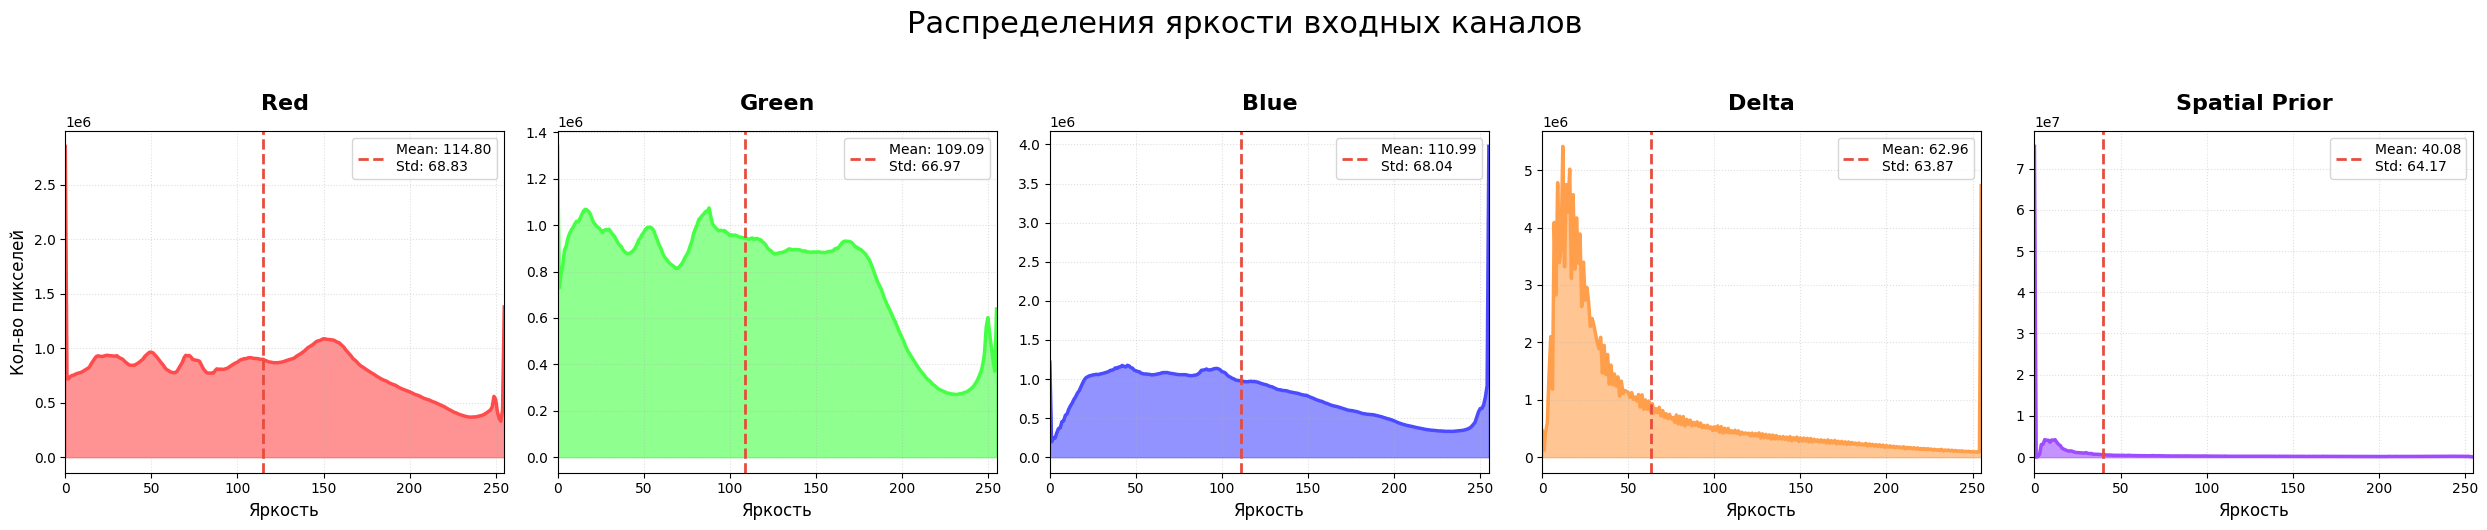

In [12]:
# график если надо
import matplotlib.pyplot as plt
def plot_histograms(hist, means, stds):
    channel_names = ['Red', 'Green', 'Blue', 'Delta', 'Spatial Prior']
    colors = ['#ff4b4b', '#44ff44', '#4b4bff', '#ff9f4b', '#9f4bff']
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    fig.suptitle('Распределения яркости входных каналов', fontsize=22, y=1.05)

    values = np.arange(256)

    for i in range(5):
        ax = axes[i]
        ax.fill_between(values, hist[i], color=colors[i], alpha=0.6)
        ax.plot(values, hist[i], color=colors[i], lw=2.5)
        ax.axvline(means[i], color='#e74c3c', linestyle='--', lw=2,
                   label=f'Mean: {means[i]:.2f}\nStd: {stds[i]:.2f}')
        ax.set_title(f'{channel_names[i]}', fontsize=16, fontweight='bold', pad=15)
        ax.set_xlim([0, 255])
        ax.set_xlabel('Яркость', fontsize=12)

        if i == 0:
            ax.set_ylabel('Кол-во пикселей', fontsize=12)
        ax.legend(loc='upper right', fontsize=10)
        ax.grid(True, alpha=0.4, linestyle=':')
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    plt.tight_layout()
    plt.show()
plot_histograms(*channel_stats(return_hist=True))
del plot_histograms

In [13]:
_means, _stds = channel_stats()  # type: ignore
CHANNEL_STATS_MEAN = torch.tensor(_means, dtype=torch.float32).view(5,1,1) / 255.0
CHANNEL_STATS_STD = torch.tensor(_stds, dtype=torch.float32).view(5,1,1) / 255.0

Загрузка: 100%|██████████| 2000/2000 [00:02<00:00, 814.03it/s]


## Augments & Dataset

In [14]:
from torchvision.transforms import v2 as tv2
from torchvision import tv_tensors
from torch.utils.data import Dataset, WeightedRandomSampler, DataLoader

In [28]:
def affine_cutmask(max_shift=40, max_scale=0.2, _ke=5, _kg=7):
    expand_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (_ke, _ke))
    _x = np.arange(256, dtype=np.float32) / 255.0
    _y = np.arange(256, dtype=np.float32)
    lut_mix = np.outer(_x, _y).round().astype(np.uint8)

    def job(t1, t2):
        # 6HW: (R,G,B,D,P,M)
        nonlocal max_shift, _kg, expand_kernel, lut_mix
        _, H, W = t1.shape
        m1,m2 = t1[5],t2[5]
        # 1. где центр
        y_idx, x_idx = np.where(m1 > 0)
        if not y_idx.any(): return t1
        cx = int(np.mean(x_idx))
        cy = int(np.mean(y_idx))
        # 2. генерация матрицы
        angle = np.random.randint(-180, 180 + 1)  # любой угл
        scale = np.random.uniform(1.0 - max_scale, 1.0 + max_scale)
        tx = np.random.randint(-max_shift, max_shift + 1)
        ty = np.random.randint(-max_shift, max_shift + 1)
        M = cv2.getRotationMatrix2D((cx, cy), angle, scale)
        M[0,2] += tx
        M[1,2] += ty
        # 3. сдвигаем маску
        m2_warped = cv2.warpAffine(m2, M, (W, H), borderMode=cv2.BORDER_CONSTANT, borderValue=0)
        if not m2_warped.any(): return t1
        # 4. сдвигаем каналы
        new_t = np.empty((6, H, W), dtype=np.uint8)
        for c in range(4):
            cv2.warpAffine(t2[c], M, (W, H), borderMode=cv2.BORDER_CONSTANT, borderValue=0, dst=new_t[c])
        # 5. глубина
        behind = t1[4] > 3
        m2_warped[~behind] = 0
        if not m2_warped.any(): return t1
        # 6. блендинг
        cutmask = np.empty((H,W), 'u1')
        cv2.dilate(m2_warped, expand_kernel, iterations=1, dst=cutmask)
        cv2.GaussianBlur(cutmask, (_kg, _kg), 0, dst=cutmask)
        cv2.add(lut_mix[255-cutmask, t1[:4]], lut_mix[cutmask, new_t[:4]], dst=new_t[:4])
        new_t[4] = t1[4]
        new_m = cv2.bitwise_or(m1, cv2.bitwise_and(m2_warped, m2_warped, mask=behind.astype('u1')))
        new_t[5] = new_m
        return new_t
    return job

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [29]:
class TrainDataset(Dataset):
    def __init__(self,
                 npy_files:list[Path],
                 img_size=352,
                 cache_samples:bool = False,
                 # Аугментации
                 cutmask_aug_p:float = 0.4,  # or 0.7
                 affine_translate:float = 0.05,  # or 0.15
                 affine_scale:float = 0.1,  # or 0.2
                 ):
        self.files = sorted(npy_files)
        self.loc2file = defaultdict(list)
        for f in self.files:
            loc = get_loc(f.name)
            self.loc2file[loc].append(f)

        self.num_samples = len(self.files)

        #### ꧁ AUGMENTS ꧂ ####
        self.cutmask_aug_p = cutmask_aug_p
        self.affine_cutmask_aug = affine_cutmask(max_shift=40)

        self.color_aug = tv2.Compose([
            tv2.RandomApply([tv2.ColorJitter(
                brightness=0.15,
                contrast=0.15)
            ], p=.5)
        ])
        self.spatial_aug = tv2.Compose([
            tv2.RandomAffine(
                degrees=0,  # type: ignore
                translate=(affine_translate, affine_translate),
                scale=(1.0-affine_scale, 1.0+affine_scale),
                fill=0),
            tv2.Resize(
                [img_size, img_size],
                antialias=True),
        ])

        self.mean = CHANNEL_STATS_MEAN
        self.std = CHANNEL_STATS_STD
        ##########################

        self.cache = ({f:np.load(f) for f in self.files}
                      if cache_samples else None)

    def __len__(self):
        return self.num_samples

    def get_tensor(self, file):
        if self.cache is not None:
            return self.cache[file].copy()
        return np.load(file)

    def __getitem__(self, idx):
        main_file = self.files[idx]
        loc = get_loc(main_file.name)

        main_t = self.get_tensor(main_file)

        if np.random.rand() < self.cutmask_aug_p:
            extra_file = np.random.choice(self.loc2file[loc])
            extra_t = self.get_tensor(extra_file)
            main_t = self.affine_cutmask_aug(main_t, extra_t)

        tensor = torch.from_numpy(main_t)
        tensor[:3] = self.color_aug(tensor[:3])

        # чтобы разные интерполяции у ресайза были
        x = tv_tensors.Image(tensor[:5])
        y = tv_tensors.Mask(tensor[5:])
        x, y = self.spatial_aug(x, y)

        x = x.float() / 255.0
        y = (y > 0).float()
        x = (x - self.mean) / self.std

        return x,y



class ValDataset(Dataset):
    def __init__(self,
                 npy_files:list[Path],
                 img_size=352,
                 cache_samples:bool = False):
        self.files = sorted(npy_files)
        self.loc2file = defaultdict(list)
        for f in self.files:
            loc = get_loc(f.name)
            self.loc2file[loc].append(f)
        self.num_samples = len(self.files)
        self.resize = tv2.Compose([
            tv2.Resize(
                [img_size, img_size],
                antialias=True),
        ])
        self.cache = ({f:np.load(f) for f in self.files}
                      if cache_samples else None)
        self.mean = CHANNEL_STATS_MEAN
        self.std  = CHANNEL_STATS_STD

    def __len__(self):
        return self.num_samples

    def get_tensor(self, file):
        if self.cache is not None:
            return self.cache[file].copy()
        return np.load(file)

    def __getitem__(self, idx):
        file = self.files[idx]
        t = self.get_tensor(file)
        tensor = torch.from_numpy(t)

        x = tv_tensors.Image(tensor[:5])
        y = tv_tensors.Mask(tensor[5:])
        x, y = self.resize(x, y)

        x = x.float() / 255.0
        y = (y > 0).float()
        x = (x - self.mean) / self.std

        return x,y

## Загрузчики

In [30]:
def create_split(loc2stems=LOCS,
                 val_ratio=VAL_RATIO,
                 ds_dir=BUILDED_DS_DIR,
                split_file:Path|None=SPLIT_TXT):
    if split_file is not None:
        trn = []
        val = []
        with open(split_file, 'r') as f:
            for line in f:
                if not line.strip(): continue
                stem, tag = [p.strip() for p in line.split(',')]
                path = ds_dir / f"{stem}.npy"
                if tag == 'trn': trn.append(path)
                elif tag == 'val': val.append(path)
        print(f"Из файла. #trn={len(trn)}, #val={len(val)}")
        return trn, val

    random.seed(SEED)
    trn = []
    val = []
    for stems in loc2stems.values():
        split = int(len(stems) * val_ratio)
        shuffled_paths = [ds_dir / f"{st}.npy" for st in random.sample(stems, len(stems))]
        val.extend(shuffled_paths[:split])
        trn.extend(shuffled_paths[split:])
    with open('split.txt', 'w') as f:
        f.write('\n'.join(map(lambda p: f"{p.stem},trn", trn)))
        f.write('\n')
        f.write('\n'.join(map(lambda p: f"{p.stem},val", val)))
    return trn, val

TRN_FILES, VAL_FILES = create_split()

Из файла. #trn=1606, #val=394


In [31]:
from torch.utils.data import WeightedRandomSampler, DataLoader


def get_loaders(
    batch_size,
    trn_epoch_multiplier:int = 10,
    cache_samples: bool = True,
    # split
    trn_files=TRN_FILES,
    val_files=VAL_FILES,
    # augments
    cutmask_aug_p:float = 0.4,      #/0.7
    affine_translate:float = 0.05,  #/0.15
    affine_scale:float = 0.1,       #/0.2
    ):
    """
    cache_samples=True для этих данных требует <1.4GB CPU RAM
    """
    train_counts = defaultdict(int)
    for f in trn_files:
        train_counts[get_loc(f.name)] += 1
    weights = torch.DoubleTensor([1.0 / train_counts[get_loc(f.name)] for f in trn_files])
    virt_num_trn = len(trn_files) * trn_epoch_multiplier

    sampler = WeightedRandomSampler(weights, num_samples=virt_num_trn, replacement=True) # type:ignore
    trn_ds = TrainDataset(
        trn_files,
        cache_samples=cache_samples,
        cutmask_aug_p=cutmask_aug_p,
        affine_translate=affine_translate,
        affine_scale=affine_scale
    )
    val_ds = ValDataset(val_files, cache_samples=cache_samples)

    tech = {"batch_size":batch_size,
            "num_workers":os.cpu_count() or 2,
            "pin_memory":True,
            "persistent_workers":True,
            "drop_last":True,
            "worker_init_fn":seed_worker,
            "generator":torch_random_gen}

    trn_loader = DataLoader(trn_ds, sampler=sampler, **tech)
    val_loader = DataLoader(val_ds, **tech)

    return trn_loader, val_loader

# Model

## Init

In [32]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

scaler = torch.amp.GradScaler("cuda") #type:ignore

def get_metrics(logits, masks, threshold=0.0):
    # t=0.0 поому что логиты. тоже самое что >0.5 от сигмоиды
    preds = (logits > threshold).float()

    tp = (preds * masks).sum(dim=(2, 3))
    fp = (preds * (1 - masks)).sum(dim=(2, 3))
    fn = ((1 - preds) * masks).sum(dim=(2, 3))

    dice = (2 * tp + 1e-7) / (2 * tp + fp + fn + 1e-7)
    iou = (tp + 1e-7) / (tp + fp + fn + 1e-7)

    return dice.mean().item(), iou.mean().item()

def train_one_epoch(model, loader, optimizer, loss_fn, scheduler, device):
    model.train()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    pbar = tqdm(loader, desc="Train", leave=False)
    for imgs, masks in pbar:
        images = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"): #type:ignore
            logits = model(images)
            loss = loss_fn(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        scheduler.step()

        loss_item = loss.item()
        dice_item, iou_item = get_metrics(logits.detach(), masks)

        running_loss += loss_item
        running_dice += dice_item
        running_iou += iou_item

        pbar.set_postfix({
            'L': f"{loss_item:.4f}",
            'Dice': f"{dice_item:.4f}",
            'LR': f"{scheduler.get_last_lr()[0]:.1e}"
        })

    n = len(loader)
    return {
        "loss": running_loss / n,
        "dice": running_dice / n,
        "iou": running_iou / n,
    }


@torch.no_grad()
def validate(model, loader, loss_fn, device):
    model.eval()
    running_loss, running_dice, running_iou = 0.0, 0.0, 0.0
    pbar = tqdm(loader, desc="Val", leave=False)

    for images, masks in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        with torch.amp.autocast("cuda"): # type:ignore
            logits = model(images)
            loss = loss_fn(logits, masks)

        dice_item, iou_item = get_metrics(logits, masks)
        running_loss += loss.item()
        running_dice += dice_item
        running_iou += iou_item

        pbar.set_postfix({'Dice': f"{dice_item:.4f}"})

    n = len(loader)
    return {
        "loss": running_loss / n,
        "dice": running_dice / n,
        "iou": running_iou / n
    }

In [35]:
# mit_b2 - средний  SegFormer
# mit_b1 - поменьше
# mit_b3 - побольше
# unet++ из-за лени раззработчиков оказался несовместим с mit
# в этом случае 1) либо поменять unet++ -> unet
#               2) либо mit -> efficientnet... но...
# 1:
model = smp.Unet(
    encoder_name="mit_b2",
    encoder_weights="imagenet",
    in_channels=5,
    classes=1,
    activation=None  # логиты
)
# # 2:
# model = smp.UnetPlusPlus(
#     encoder_name="efficientnet-b3",
#     encoder_weights="imagenet",
#     ...
# )
# морозим энкодер (все кроме первого слоя)
for name, param in model.encoder.named_parameters():
    if "patch_embed1.proj" not in name:  # = имя первого слоя у mit
        param.requires_grad = False      # у эфишнета это conv_stem

model = model.cuda()

optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-2
)

# лосс
dice_loss = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=True)
focal_loss  = smp.losses.FocalLoss(smp.losses.BINARY_MODE)
def criterion(y_pred, y_true):
    return 0.5 * focal_loss(y_pred, y_true) + 0.5 * dice_loss(y_pred, y_true)


device = torch.device("cuda")

## ФАЗА 1

In [ ]:
# # Почистить куду:
# import gc
# gc.collect()
# torch.cuda.empty_cache()

In [ ]:
EPOCHS_PHASE_1 = 15

# всего картинок 2к, val_ratio к примеру 20%
# trn_epoch_multiplier -> m, batch_size -> b  | для em=10, b=32:
# 2000*80% ~1600  -- сэмплов в трейне         | ...
# 1600*m   -- "картнок" на обучение в эпоху   | ~16000
# 1600*m/b -- шагов за эпоху (один шаг это b) | ~500
# em=10, b=64 не влазит, зато b=48 влазит но в притык по ram - тут опасно
trn_loader, val_loader = get_loaders(batch_size=48, trn_epoch_multiplier=10)

scheduler = OneCycleLR(
    optimizer,
    max_lr=1e-3,
    epochs=EPOCHS_PHASE_1,
    steps_per_epoch=len(trn_loader),
    pct_start=0.1 # 10%
)

best_dice = 0.0

print(f"ФАЗА 1: ЭНКОДЕР ЗАМОРОЖЕН")
for epoch in range(1, EPOCHS_PHASE_1 + 1):
    train_logs = train_one_epoch(model, trn_loader, optimizer, criterion, scheduler, device)
    val_logs = validate(model, val_loader, criterion, device)

    print(f"Epoch {epoch:02d} | "
          f"Train Loss: {train_logs['loss']:.4f} Dice: {train_logs['dice']:.4f} | "
          f"Val Loss: {val_logs['loss']:.4f} Dice: {val_logs['dice']:.4f}")

    if val_logs['dice'] > best_dice:
        best_dice = val_logs['dice']
        torch.save(model.state_dict(), "best_model_phase1.pth")
        print("Новая Лучшая, сохранено")

## ФАЗА 2

In [ ]:
del trn_loader, val_loader, optimizer
import gc; gc.collect()
torch.cuda.empty_cache()

In [36]:
EPOCHS_PHASE_2 = 30

print("ФАЗА 2: РАЗМОРОЗКА ЭНКОДЕРА И ФАЙНТЮН")
# model.load_state_dict(torch.load("best_model_phase1.pth"))
model.load_state_dict(torch.load("/kaggle/input/datasets/aaaaa982/123123/best_model_phase1.pth"))


trn_loader, val_loader = get_loaders(
    batch_size=48,
    trn_epoch_multiplier=10,
    # Модель переобучается неслабо на первой фазе,
    # А потому усилим агументы на вторую
    cutmask_aug_p = 0.7,  # 70% синтектики вместо дефолтных 40%
    affine_translate = 0.15,  # сдвиг x3 (дефолт .5)
    affine_scale = 0.2        # скейл x2 (дефолт .1)
)

for param in model.parameters():  # снимаем с цепи транформера
    param.requires_grad = True


optimizer = AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-1  # вместо 1e-2, чтобы убрать Train Dice: 100%
    # хотя возможно много и стоило попробовать 0.05, ну да ладно
)

scheduler_phase2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS_PHASE_2 * len(trn_loader),
    eta_min=1e-6
)

# best_dice_phase2 = best_dice
best_dice_phase2 = 0.8744
# best_dice_phase2 = 0.9289

for epoch in range(1, EPOCHS_PHASE_2 + 1):
    train_logs = train_one_epoch(model, trn_loader, optimizer, criterion, scheduler_phase2, device)
    val_logs = validate(model, val_loader, criterion, device)

    print(f"P2 Epoch {epoch:02d} | "
          f"Train L: {train_logs['loss']:.4f} D: {train_logs['dice']:.4f} | "
          f"Val L: {val_logs['loss']:.4f} D: {val_logs['dice']:.4f}")

    if val_logs['dice'] > best_dice_phase2:
        best_dice_phase2 = val_logs['dice']
        torch.save(model.state_dict(), "best_model_FINAL.pth")
        print("Новая Альфа, сохранено")

ФАЗА 2: РАЗМОРОЗКА ЭНКОДЕРА И ФАЙНТЮН


P2 Epoch 01 | Train L: 0.0262 D: 0.9554 | Val L: 0.0716 D: 0.8770
Новая Альфа, сохранено


P2 Epoch 02 | Train L: 0.0236 D: 0.9590 | Val L: 0.0717 D: 0.8839
Новая Альфа, сохранено


P2 Epoch 03 | Train L: 0.0216 D: 0.9626 | Val L: 0.0741 D: 0.8811


P2 Epoch 04 | Train L: 0.0204 D: 0.9640 | Val L: 0.0707 D: 0.8848
Новая Альфа, сохранено


...

P2 Epoch 26 | Train L: 0.0125 D: 0.9774 | Val L: 0.0748 D: 0.8927


P2 Epoch 27 | Train L: 0.0125 D: 0.9775 | Val L: 0.0759 D: 0.8915


P2 Epoch 28 | Train L: 0.0124 D: 0.9774 | Val L: 0.0755 D: 0.8920


P2 Epoch 29 | Train L: 0.0124 D: 0.9775 | Val L: 0.0755 D: 0.8923


P2 Epoch 30 | Train L: 0.0124 D: 0.9780 | Val L: 0.0756 D: 0.8925
